# What is Feature Engineering in Machine Learning?

Feature engineering means selecting the right features from existing data.

# Types of Features in Machine Learning

### Numerical Features

Numerical features represent data in numbers. They are continuous quantitative variables.

### Categorical Features

A categorical column can contain only discrete features. Categorical variables are further divided into binary and non-binary types. Binary categorical features can take only two values, while non-binary categorical features can take more than two values.

### Textual and time-series features

Textual columns contain only text data. Time-series features represent timely data, such as weekly sales or stock price fluctuations over a year.

# Feature Engineering Techniques

### Handling missing values

- Imputation: Imputation is the process of filling missing values using available data. For instance, you can use mean, mode, and median to replace missing values.
- Deletion: Deletion removes rows with missing values and is most suitable when missing data is less than 10% of the dataset size.

### Handling outliers

Outliers are abnormal values that are significantly different from the rest of the data. Outliers can be handled using the following techniques:
- Replace: We can replace outliers with a statistical value, such as the mean or median of the column.
- Transformation: Apply transformations like log or square root to reduce the effect of outliers.
- Robust models: Use models that are less sensitive to outliers, such as decision trees, gradient boosting, and ridge regression.
- Deletion: Remove outliers from the dataset.

### Encoding categorical features

Machine learning models cannot directly work with categorical values, so we must convert them into numerical values. There are some techniques to encode categorical features:
- One-hot encoding
- Label encoding
- Ordinal encoding
- Target encoding

### Feature scaling

Feature scaling ensures that numerical values lie within a standardized range, preventing some features from dominating others due to their larger values.

Machine learning models that rely on distance-based calculations(linear regression, KNN and neural networks) can be affected when features have vastly different scales

There are two common methods for feature scaling:
- Normalization (min-max scaling): This method scale all values to fall within a range of 0 to 1. It subtracts the minimum value of the column from each data point and then divides by the range of the column (max - min).
    - Formula: (x - min(column)) / (max(column) - min(column))
- Standardization( z-score scaling): This transforms all the features to have mean of 0 and standard deviation of 1. This is done by subtracting the mean of the column from each data point and then dividing by the standard deviation of the column.
    - Formula: (x - mean(column)) / std(column)

### Creating new features

Creating new and meaningful features from existing data can provide more logical insights.

For example, if we have the `length` and `width` of a ground, we can create a new feature called `area` by multiplying the two features, which can provide more information about the `price`. So inputting the `area` feature into the model can improve its performance through discovering new hidden patterns in the data.

### Feature selection

Feature selection keeps only relevant features by removing unnecessary columns. Focusing on the most informative data helps prevent overfitting, reduce computational complexity, and improve model performance. There are two main types of feature selection techniques:
- Filter methods: This method selects important features based on their statistical properties. For instance, we can remove features that carry the same information using a correlation matrix. We can also use statistical tests like Chi-square, ANOVA, and Pearson correlation to select relevant features.
- Wrapper methods: This method evaluates subsets of features by training and testing the model on each subset. The goal is to find the best combination of features that maximizes the model's performance.

# A Python example

### Handling categorical missing values

In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/jethzgg/Data-ML/refs/heads/main/Data%20Preprocessing/Feature%20Engineering/train.csv")

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Replace missing values with the most frequent category
for col in categorical_cols:
    mode = df[col].mode()[0]
    df[col].fillna(mode, inplace=True)

/tmp/ipykernel_11335/3996667370.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode, inplace=True)


### Handling numeric missing values
Mean is a more popular option for statistically distributed data, while median works well when the column has outliers. So, we will check for outliers and decide on the method. 

/usr/local/lib/python3.13/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1267: RuntimeWarning: invalid value encountered in less_equal
  wiskhi = x[x <= hival]
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1274: RuntimeWarning: invalid value encountered in greater_equal
  wisklo = x[x >= loval]
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1282: RuntimeWarning: invalid value encountered in less
  x[x < stats['whislo']],


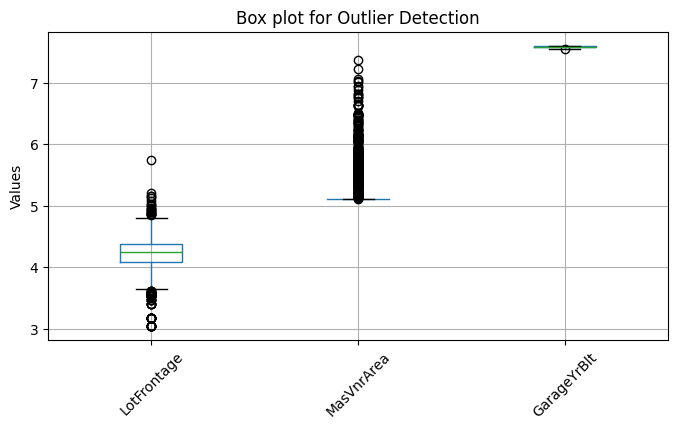

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = ["LotFrontage", "MasVnrArea", "GarageYrBlt"]

# Plot box plots
df[features] = np.log(df[features])
df[features].boxplot(figsize=(8,4))

plt.title("Box plot for Outlier Detection")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

In [4]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns
for col in numerical_columns:
    median = df[col].median()  
    df[col].fillna(median, inplace=True)  # Replace nulls with median

/tmp/ipykernel_11335/1103635297.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median, inplace=True)  # Replace nulls with median
/tmp/ipykernel_11335/1103635297.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

### Creating new features
Columns like `YearBuilt`, `YeahRemodAdd`, `GarageTrBlt`, and `YrSold` contain years that do not directly provide information about the price. We can derive more useful insights by calculating how old the house or renovation is at the same time of sale.

In [5]:
# Get columns that contain 'Yr' or 'Year'
year_columns = [feature for feature in numerical_columns if 'Yr' in feature or 'Year' in feature]

# Convert year values into age-related features
for col in year_columns:
    df[col] = df['YrSold'] - df[col]

### Feature transformation
In machine learning, skewed numerical features can negatively impact model performance. Before applying a log transformation, we must identify skewed features. However, we exclude columns containing zeros since the logarithm of zero is undefined.

In [6]:
import pandas as pd

# Get numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

# Identify columns containing zeros
numerical_0s = df.loc[:, (df == 0).any()].select_dtypes(include=['number']).columns

# Remove columns that contain zeros from consideration
numerical_columns = numerical_columns.difference(numerical_0s)

# Calculate skewness for the remaining numerical columns
skewness = df[numerical_columns].skew()

# Set threshold for skewness (e.g., absolute value > 1 indicates high skewness)
skewed_columns = skewness[abs(skewness) > 1]

# Display skewed columns
print("Skewed Columns:")
print(skewed_columns)

Skewed Columns:
GrLivArea       1.186075
LotArea        12.348242
LotFrontage    -1.024363
MSSubClass      1.404451
SalePrice       1.963159
dtype: float64


In [7]:
import numpy as np

# The list of highly skewed features identified earlier
skew_features = ['LotFrontage', 'LotArea', '1stFlrSF', 'GrLivArea', 'SalePrice']

# Apply log transformation to each skewed feature
for col in skew_features:
    df[col] = np.log(df[col])

### Encoding categorical features

In [8]:
# Select categorical variables
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Apply target encoding
for col in categorical_columns:
    # Compute mean SalePrice for each category
    labels_ordered = df.groupby([col])['SalePrice'].mean().sort_values().index
    
    # Assign numerical values based on target variable mean
    labels_ordered = {x: i for i, x in enumerate(labels_ordered, 0)}
    
    # Map encoded values back to the dataframe
    df[col] = df[col].map(labels_ordered)